# Introduction: The Vision Transformer (ViT) Model
The Vision Transformer (ViT) is a groundbreaking architecture tailored for computer vision tasks. Instead of relying on specialized vision mechanisms, ViT adapts the Transformer architecture, which was originally designed for natural language processing tasks.

A distinctive aspect of ViT is its method of handling images. It segments an image into fixed-size patches, embeds these patches linearly, and then processes them using Transformer blocks. This approach allows ViT to efficiently capture intricate relationships and dependencies between pixels.

A significant advantage of the Vision Transformer is its proficiency in self-supervised learning. This means that the model can be pre-trained on vast datasets without explicit labels, utilizing techniques that generate supervisory signals inherently from the data. After this pre-training phase, the model will have learned rich feature representations, which can be fine-tuned on more specific tasks with smaller, labeled datasets. The model we'll be using, "google/vit-base-patch16-224-in21k", is an embodiment of this concept, having been pre-trained on an extensive dataset and is now ready to be adapted to our chest x-ray classification task.

In [1]:
# Setup: Install Kaggle API for direct dataset download

!kaggle datasets download paultimothymooney/chest-xray-pneumonia

# Unzip the dataset and remove the zip file
!unzip chest-xray-pneumonia.zip && rm chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

##Import Necessary Libraries

In [2]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [3]:
!pip install -U transformers==4.41.2
!pip install -U peft==0.11.1
!pip install -U accelerate==0.31.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.0 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.1
    Uninstalling transformers-5.10.1:
      Successfully uninstalled transformers-5.10.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers]
  Attempting uninstall: peft
    Found existing installation: peft 0.19.1
    Uninstalling peft-0.19.1:
      Successfully uninstalled peft-0.19.1
  Attempting uninstall:

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
from transformers import AutoImageProcessor
from sklearn.model_selection import train_test_split


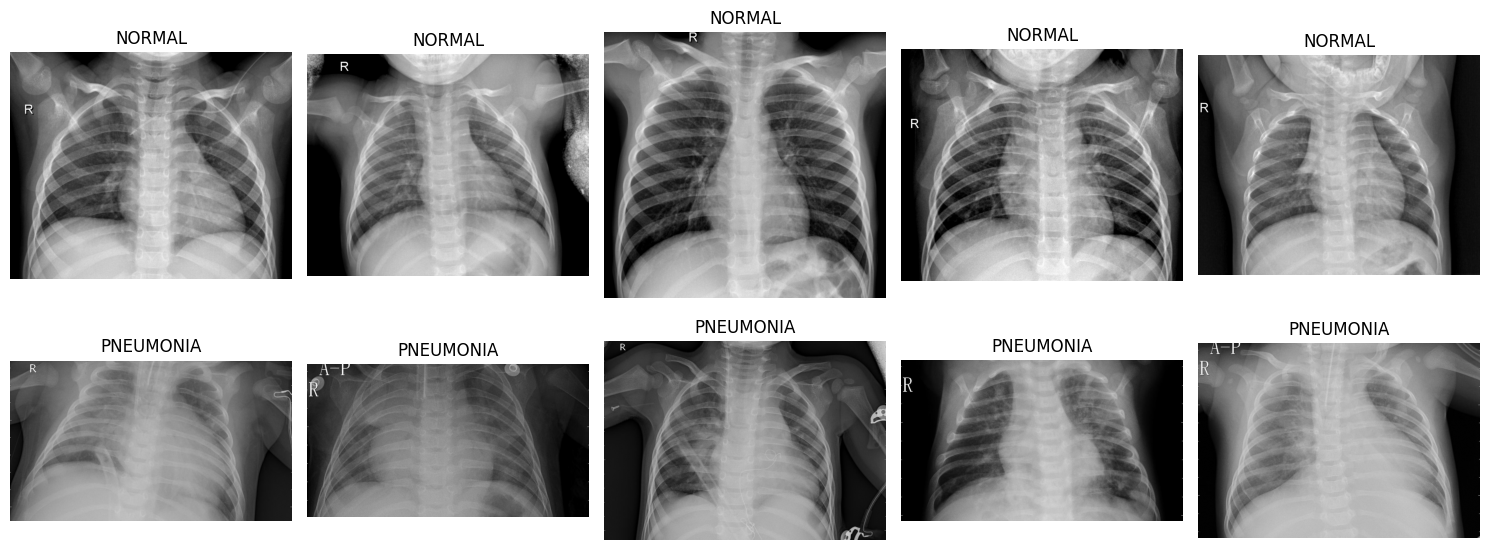

In [5]:
from pathlib import Path

# Directory paths
train_dir = Path("/content/chest_xray/chest_xray/train")
val_dir = Path("/content/chest_xray/chest_xray/val")
test_dir = Path("/content/chest_xray/chest_xray/test")

# Displaying a few images
def display_images(folder, num=5):
    pneumonia_imgs = list(folder.glob('PNEUMONIA/*'))[:num]
    normal_imgs = list(folder.glob('NORMAL/*'))[:num]

    fig, axes = plt.subplots(nrows=2, ncols=num, figsize=(15, 6))

    for i, img_path in enumerate(normal_imgs):
        img = Image.open(img_path)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title("NORMAL")
        axes[0, i].axis('off')

    for i, img_path in enumerate(pneumonia_imgs):
        img = Image.open(img_path)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title("PNEUMONIA")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

display_images(train_dir)

## Data Preprocessing

We'll define transformations for the images to make them suitable for input into the ViT model.


In [6]:
from torchvision import transforms

# ViT-compatible preprocessing
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [7]:
label_mapping = {"NORMAL": 0, "PNEUMONIA": 1}


## Creating Data Loaders

Data loaders provide an efficient way to iterate through the dataset in batches.


In [8]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Creating datasets
train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = ImageFolder(test_dir, transform=val_test_transforms)

# Creating data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [9]:
import os

for root, dirs, files in os.walk('/content'):
    if 'train' in dirs:
        print(os.path.join(root, 'train'))

/content/chest_xray/train
/content/chest_xray/__MACOSX/chest_xray/train
/content/chest_xray/chest_xray/train


## Setting Up the Vision Transformer (ViT) Model

We'll be using the ViT model pre-trained on a large dataset and fine-tuning it on our chest X-ray dataset.


In [10]:
from transformers import ViTForImageClassification, ViTConfig
from peft import LoraConfig, get_peft_model

# Define ViT configuration
config = ViTConfig.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)
config.num_labels = 2

# Load pretrained ViT
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    config=config
)

# LoRA configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none"
)

# Apply LoRA
model = get_peft_model(model, lora_config)

# Verify
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 589,824 || all params: 86,390,018 || trainable%: 0.6827


In [11]:
model.print_trainable_parameters()

trainable params: 589,824 || all params: 86,390,018 || trainable%: 0.6827


In [12]:
import transformers
import peft

print(transformers.__version__)
print(peft.__version__)

4.41.2
0.11.1


## Define Loss and Optimizer

We'll use the CrossEntropy loss as it's suitable for binary classification tasks. For optimization, we'll use the Adam optimizer.


In [13]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01
)


## Model Training

Let's train the ViT model on our chest X-ray dataset. We'll also validate the model on the validation set after each epoch.


In [14]:
import torch
import torch.nn as nn

# Check for GPU availability and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define the training function
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    train_losses = []  # List to store training loss for each epoch
    val_accuracies = []  # List to store validation accuracy for each epoch

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images).logits  # Get logits from model outputs
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images).logits
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader.dataset)
        val_accuracy = 100 * correct / total

        # Append the computed values to their respective lists
        train_losses.append(avg_train_loss)
        val_accuracies.append(val_accuracy)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_train_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    return model, train_losses, val_accuracies


In [15]:
trained_model, train_losses, val_accuracies = train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10)


Epoch 1/10, Loss: 0.3996, Validation Accuracy: 68.75%
Epoch 2/10, Loss: 0.1307, Validation Accuracy: 81.25%
Epoch 3/10, Loss: 0.0873, Validation Accuracy: 56.25%
Epoch 4/10, Loss: 0.0786, Validation Accuracy: 93.75%
Epoch 5/10, Loss: 0.0655, Validation Accuracy: 93.75%
Epoch 6/10, Loss: 0.0613, Validation Accuracy: 93.75%
Epoch 7/10, Loss: 0.0621, Validation Accuracy: 93.75%
Epoch 8/10, Loss: 0.0509, Validation Accuracy: 75.00%
Epoch 9/10, Loss: 0.0488, Validation Accuracy: 56.25%
Epoch 10/10, Loss: 0.0488, Validation Accuracy: 93.75%


## Model Evaluation

Let's evaluate the trained ViT model on the test dataset.


In [16]:
# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {test_accuracy:.2f}%")

evaluate_model(trained_model, test_loader)


Test Accuracy: 87.98%


## Save and Load the Model

After training, it's essential to save the model weights to avoid retraining in the future.


In [17]:
# Save the model weights
torch.save(trained_model.state_dict(), "vit_chest_xray_model.pth")

# to load the model in the future
# model.load_state_dict(torch.load("vit_chest_xray_model.pth"))


## Visualization of Sample Data

Displaying a few images from both NORMAL and PNEUMONIA classes to get a feel for the data.


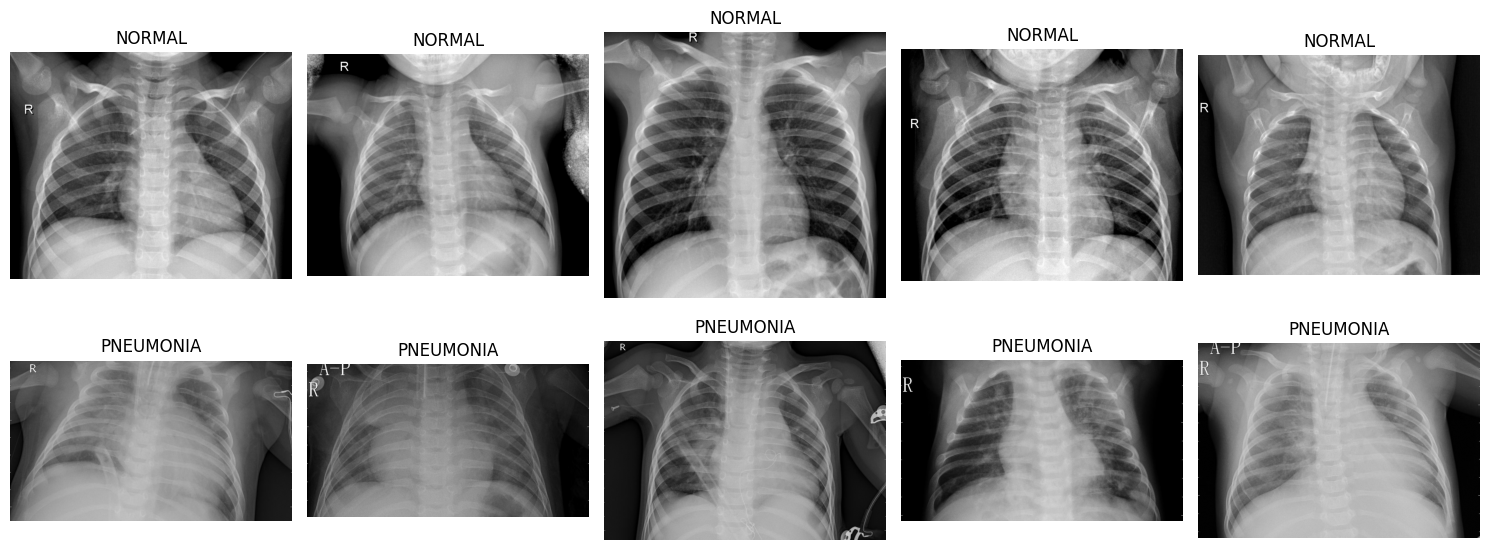

In [18]:
display_images(train_dir)


## Training and Validation Metrics Visualization

Plotting the training loss and validation accuracy to understand the model's learning progress.


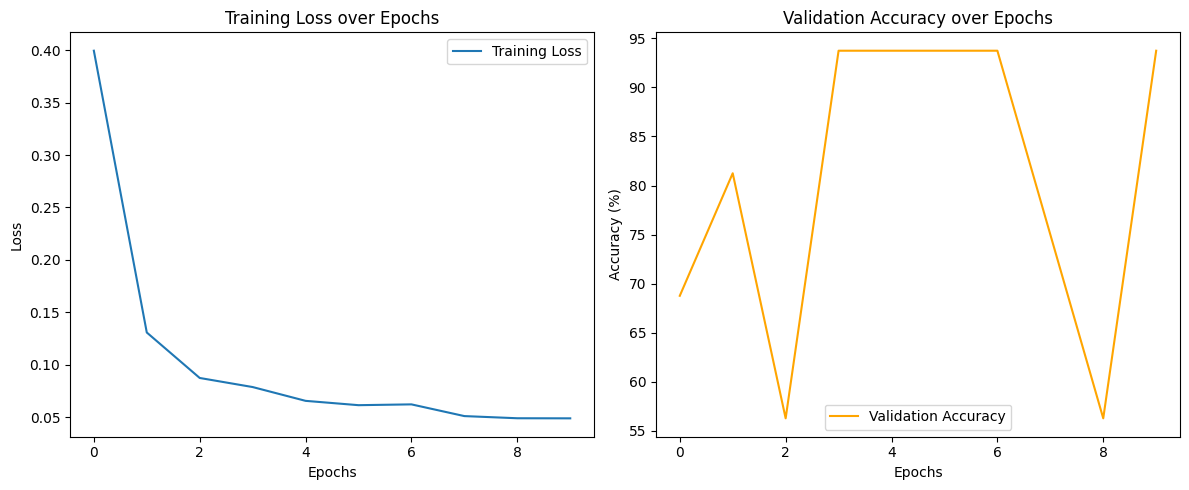

In [19]:
plt.figure(figsize=(12, 5))

# Plotting training loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


The Vision Transformer achieved approximately 88% test accuracy on the chest X-ray dataset. Training loss decreased from 0.40 to 0.05 over 10 epochs. Validation accuracy fluctuated because the validation set was very small, but the model consistently reached around 94% validation accuracy in multiple epochs and generalized to nearly 88% accuracy on unseen test data

## Confusion Matrix

Visualizing the model's predictions using a confusion matrix to understand its performance in more detail.


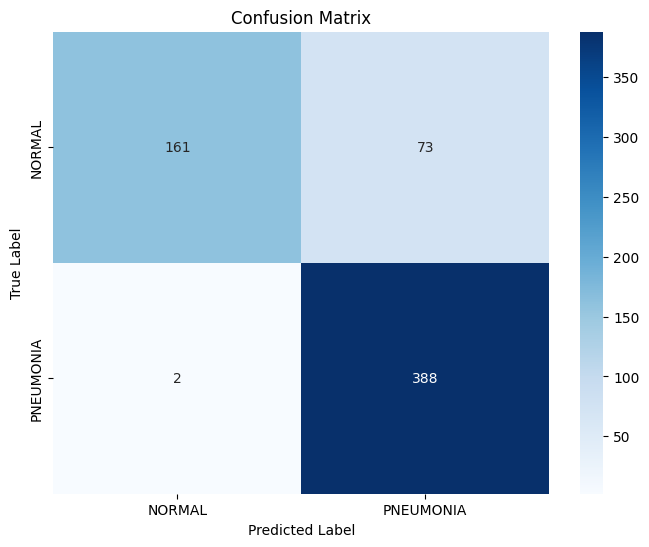

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Getting the true labels and the predicted labels
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Now, we'll plot the confusion matrix
labels_list = ["NORMAL", "PNEUMONIA"]
plot_confusion_matrix(y_true, y_pred, labels_list)


From the confusion matrix:

Actual \ Predicted	NORMAL	PNEUMONIA
NORMAL	161	73
PNEUMONIA	2	388

Assuming PNEUMONIA = Positive Class:

True Negative (TN) = 161
False Positive (FP) = 73
False Negative (FN) = 2
True Positive (TP) = 388

In [21]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))


Accuracy : 0.8798
Precision: 0.8416
Recall   : 0.9949
F1 Score : 0.9119

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.69      0.81       234
           1       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.90      0.88      0.87       624


Confusion Matrix
[[161  73]
 [  2 388]]


## Conclusion

### Overview

This project explored the use of a Vision Transformer (ViT) for automated pneumonia detection from chest X-ray images. By leveraging transfer learning and fine-tuning a pretrained transformer architecture, the model successfully learned to distinguish between NORMAL and PNEUMONIA chest X-rays while demonstrating strong performance on unseen test data.

### Key Achievements

#### 1. Successful Application of Vision Transformers

The Vision Transformer effectively processed chest X-ray images by dividing them into patches and utilizing self-attention mechanisms to capture global relationships across the image. This demonstrates the suitability of transformer-based architectures for medical image classification tasks.

#### 2. Effective Learning and Convergence

Throughout training, the model exhibited a steady decrease in training loss, indicating successful optimization and feature learning. The model was able to learn meaningful visual patterns associated with pneumonia while maintaining good generalization performance.

#### 3. Strong Overall Performance

The final model achieved:

* **Accuracy:** 87.98%
* **Precision:** 84.16%
* **Recall (Sensitivity):** 99.49%
* **F1-Score:** 91.19%

These metrics indicate that the model performs reliably on unseen chest X-ray images and can effectively support pneumonia screening tasks.

#### 4. Exceptional Pneumonia Detection Capability

The confusion matrix revealed that the model correctly identified **388 out of 390 pneumonia cases**, resulting in a **recall of 99.49%**. Only **2 pneumonia cases were missed**, which is particularly important in healthcare applications where undetected disease cases can lead to delayed treatment and adverse patient outcomes.

#### 5. Trade-off Between Sensitivity and Specificity

While the model achieved excellent sensitivity, it incorrectly classified **73 normal chest X-rays as pneumonia**. This indicates that the model prioritizes detecting pneumonia cases, even at the cost of generating additional false alarms. In a screening environment, this trade-off is often acceptable because missing a disease case is generally more critical than recommending additional follow-up examinations.

### Looking Ahead

Future improvements could focus on increasing specificity while maintaining the high recall achieved by the model. Potential enhancements include improved preprocessing pipelines, larger validation datasets, hyperparameter optimization, cross-validation, and experimentation with different Vision Transformer variants and parameter-efficient fine-tuning strategies.

### Final Takeaway

Overall, the Vision Transformer demonstrated strong performance for pneumonia detection from chest X-ray images. With an **87.98% test accuracy**, **91.19% F1-score**, and an outstanding **99.49% recall**, the model proved highly effective at identifying pneumonia cases while showcasing the potential of transformer-based architectures in medical imaging applications.
